<a href="https://colab.research.google.com/github/panavgohil/ML-Assignment-2/blob/main/MNIST_Classification_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [22]:
#upload and extract dataset
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [23]:
import os
print(os.listdir())

['.config', 'archive (1) (1).zip', 'mnist', 'archive (1).zip', 'sample_data']


In [24]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('mnist')

import os
print(os.listdir('mnist'))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'train-images-idx3-ubyte', 't10k-labels.idx1-ubyte', 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte', 't10k-images.idx3-ubyte', 'train-labels-idx1-ubyte']


In [25]:
!pip install idx2numpy

In [26]:
import idx2numpy
X_train = idx2numpy.convert_from_file(
    'mnist/train-images.idx3-ubyte'
)
y_train = idx2numpy.convert_from_file(
    'mnist/train-labels.idx1-ubyte'
)
X_test = idx2numpy.convert_from_file(
    'mnist/t10k-images.idx3-ubyte'
)
y_test = idx2numpy.convert_from_file(
    'mnist/t10k-labels.idx1-ubyte'
)

In [27]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


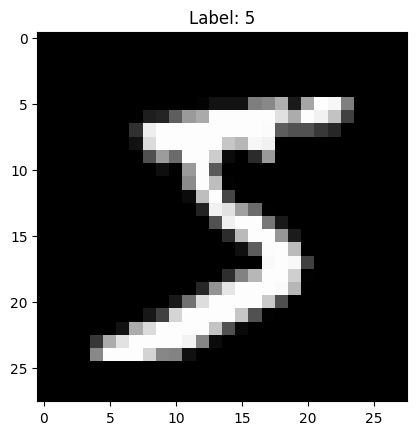

In [28]:
#visualize sample image
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [29]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [30]:
print(y_train[0])

5


In [31]:
#Data Preprocessing, Normalization:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [32]:
#verify:
print(X_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [33]:
#building the neural n/w:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten


In [34]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [35]:
#model architecture:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9216 - loss: 0.2663 - val_accuracy: 0.9611 - val_loss: 0.1314
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9659 - loss: 0.1135 - val_accuracy: 0.9657 - val_loss: 0.1092
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9761 - loss: 0.0784 - val_accuracy: 0.9708 - val_loss: 0.1000
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9815 - loss: 0.0576 - val_accuracy: 0.9709 - val_loss: 0.1013
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9840 - loss: 0.0480 - val_accuracy: 0.9712 - val_loss: 0.1058
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9873 - loss: 0.0375 - val_accuracy: 0.9753 - val_loss: 0.0969
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9763 - val_loss: 0.0954
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9915 - loss: 0.0252 

In [38]:
loss, accuracy= model.evaluate(X_test,y_test)
print("test loss= ",loss)
print("test accuracy= ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9743 - loss: 0.1050
test loss=  0.10503754019737244
test accuracy=  0.9743000268936157


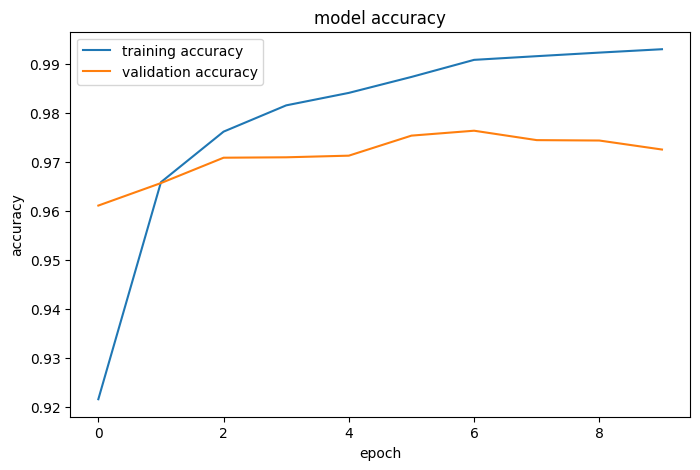

In [39]:
#accuracy curve
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend([ 'training accuracy','validation accuracy'])
plt.show()

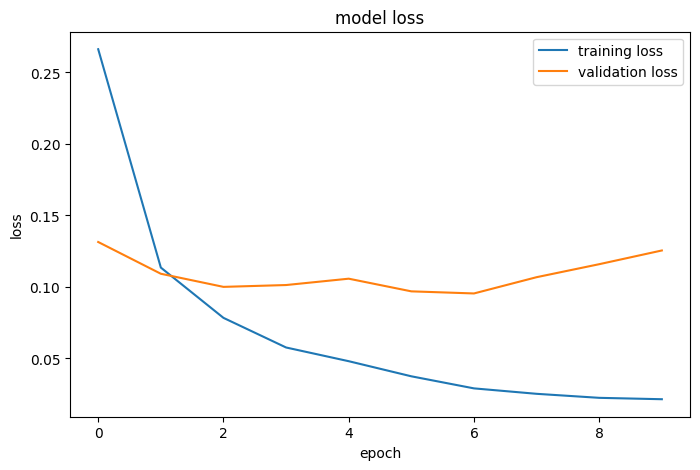

In [40]:
#loss curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model loss")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend([ 'training loss','validation loss'])
plt.show()

In [41]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [44]:
y_pred=model.predict(X_test)
y_pred_classes=np.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [45]:
cm=confusion_matrix(y_test,y_pred_classes)

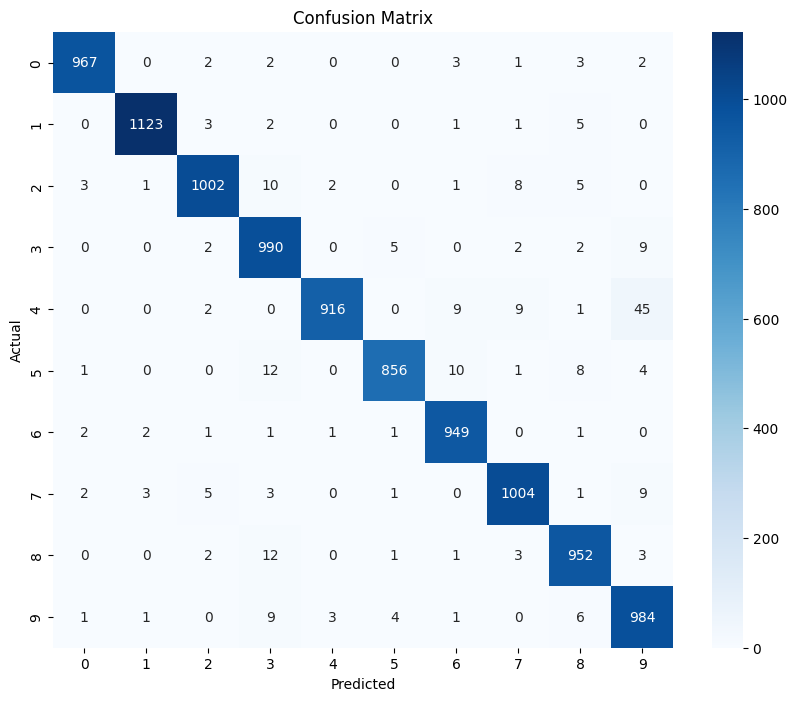

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

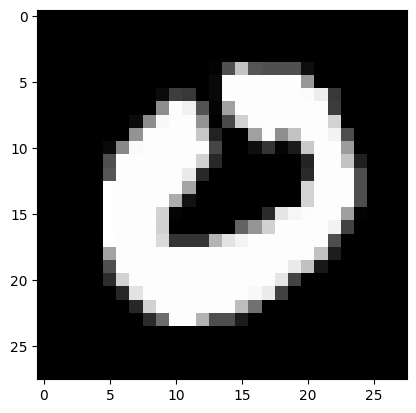

In [47]:
#sample prediction:
idx = 25

plt.imshow(
    X_test[idx],
    cmap='gray'
)

plt.show()

In [48]:
prediction = np.argmax(
    model.predict(
        X_test[idx].reshape(1,28,28)
    )
)

print("Predicted:", prediction)
print("Actual:", y_test[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Predicted: 0
Actual: 0


##NAME: PANAV GOHIL
##ROLL NUMBER: 25/A14/031

Objective:
Build a Neural Network model to classify handwritten digits (0–9) using the MNIST dataset.